In [ ]:
!pip install kagglehub -q

In [ ]:
import kagglehub, os, random, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB0

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
path = kagglehub.dataset_download("tushar5harma/plant-village-dataset-updated")
print("Dataset path:", path)
BASE_DIR = path

Using Colab cache for faster access to the 'plant-village-dataset-updated' dataset.
Dataset path: /kaggle/input/plant-village-dataset-updated


In [ ]:
all_train_dirs = []
all_val_dirs   = []
all_test_dirs  = []
all_class_names = set()

for plant_folder in sorted(os.listdir(BASE_DIR)):
    plant_path = os.path.join(BASE_DIR, plant_folder)
    if not os.path.isdir(plant_path):
        continue
    train_path = os.path.join(plant_path, 'Train')
    val_path   = os.path.join(plant_path, 'Val')
    test_path  = os.path.join(plant_path, 'Test')

    if os.path.isdir(train_path):
        all_train_dirs.append(train_path)
        for disease_folder in sorted(os.listdir(train_path)):
            if os.path.isdir(os.path.join(train_path, disease_folder)):
                all_class_names.add(disease_folder)
    if os.path.isdir(val_path):
        all_val_dirs.append(val_path)
    if os.path.isdir(test_path):
        all_test_dirs.append(test_path)

CLASS_NAMES = sorted(list(all_class_names))
NUM_CLASSES = len(CLASS_NAMES)
print(f"Jumlah kelas   : {NUM_CLASSES}")
print(f"Contoh kelas   : {CLASS_NAMES[:5]}")
print(f"Plant folders  : {len(all_train_dirs)}")

Jumlah kelas   : 16
Contoh kelas   : ['Apple Scab', 'Bacterial Spot', 'Black Rot', 'Cedar Apple Rust', 'Cercospora Leaf Spot']
Plant folders  : 9


In [ ]:
import shutil

FLAT_TRAIN = '/content/flat_train'
FLAT_VAL   = '/content/flat_val'
FLAT_TEST  = '/content/flat_test'

for flat_dir, source_dirs in [
    (FLAT_TRAIN, all_train_dirs),
    (FLAT_VAL,   all_val_dirs),
    (FLAT_TEST,  all_test_dirs)
]:
    if os.path.exists(flat_dir):
        shutil.rmtree(flat_dir)
    os.makedirs(flat_dir)

    for src in source_dirs:
        for disease_folder in sorted(os.listdir(src)):
            disease_path = os.path.join(src, disease_folder)
            if os.path.isdir(disease_path):
                dst = os.path.join(flat_dir, disease_folder)
                if not os.path.exists(dst):
                    os.symlink(disease_path, dst)

print(f"flat_train kelas : {len(os.listdir(FLAT_TRAIN))}")
print(f"flat_val kelas   : {len(os.listdir(FLAT_VAL))}")
print(f"flat_test kelas  : {len(os.listdir(FLAT_TEST))}")

flat_train kelas : 16
flat_val kelas   : 16
flat_test kelas  : 16


In [ ]:
total_train = sum(len(os.listdir(os.path.join(FLAT_TRAIN, c)))
                  for c in os.listdir(FLAT_TRAIN)
                  if os.path.isdir(os.path.join(FLAT_TRAIN, c)))
total_val   = sum(len(os.listdir(os.path.join(FLAT_VAL, c)))
                  for c in os.listdir(FLAT_VAL)
                  if os.path.isdir(os.path.join(FLAT_VAL, c)))
total_test  = sum(len(os.listdir(os.path.join(FLAT_TEST, c)))
                  for c in os.listdir(FLAT_TEST)
                  if os.path.isdir(os.path.join(FLAT_TEST, c)))
print(f"\nTotal gambar train : {total_train}")
print(f"Total gambar val   : {total_val}")
print(f"Total gambar test  : {total_test}")


Total gambar train : 29825
Total gambar val   : 6705
Total gambar test  : 752


In [ ]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 5
SEED       = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"Jumlah kelas  : {NUM_CLASSES}")
print(f"Ukuran gambar : {IMG_SIZE}")
print(f"Batch size    : {BATCH_SIZE}")

Jumlah kelas  : 16
Ukuran gambar : (128, 128)
Batch size    : 32


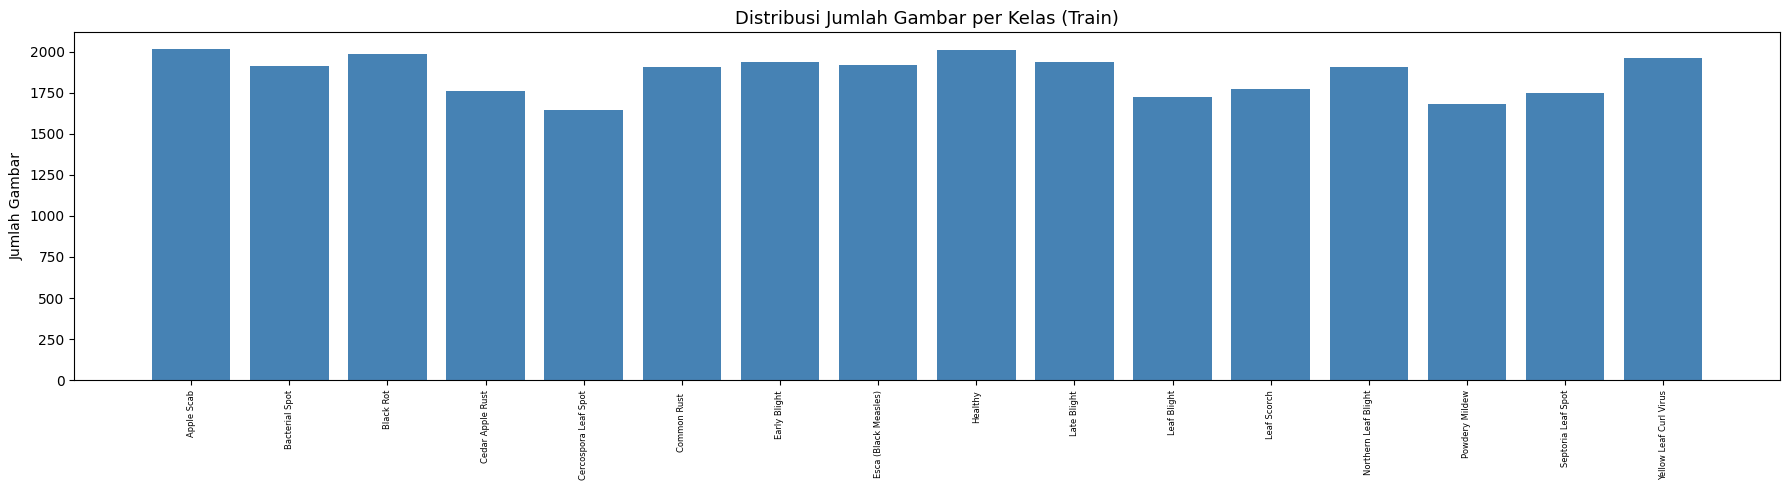

Total : 29825
Rata  : 1864
Min   : 1642
Max   : 2016


In [ ]:
class_counts = {}
for cls in sorted(os.listdir(FLAT_TRAIN)):
    cls_path = os.path.join(FLAT_TRAIN, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

plt.figure(figsize=(18, 5))
plt.bar(range(len(class_counts)), list(class_counts.values()), color='steelblue')
plt.xticks(range(len(class_counts)), list(class_counts.keys()),
           rotation=90, fontsize=6)
plt.title("Distribusi Jumlah Gambar per Kelas (Train)", fontsize=13)
plt.ylabel("Jumlah Gambar")
plt.tight_layout()
plt.show()

print(f"Total : {sum(class_counts.values())}")
print(f"Rata  : {int(np.mean(list(class_counts.values())))}")
print(f"Min   : {min(class_counts.values())}")
print(f"Max   : {max(class_counts.values())}")

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    FLAT_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED,
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    FLAT_VAL,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED,
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    FLAT_TEST,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED,
    shuffle=False
)

print(f"\nTraining samples : {train_gen.samples}")
print(f"Val samples      : {val_gen.samples}")
print(f"Test samples     : {test_gen.samples}")
print(f"Jumlah kelas     : {train_gen.num_classes}")

Found 29827 images belonging to 16 classes.
Found 6705 images belonging to 16 classes.
Found 755 images belonging to 16 classes.

Training samples : 29827
Val samples      : 6705
Test samples     : 755
Jumlah kelas     : 16


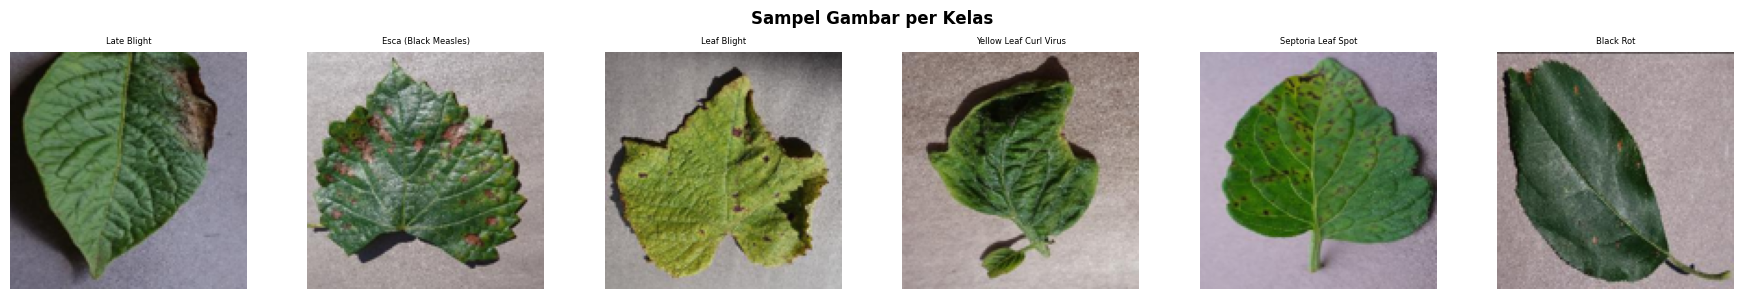

In [ ]:
from PIL import Image as PILImage

def show_sample_images(flat_dir, n_classes=6):
    cls_list = sorted(os.listdir(flat_dir))
    selected = random.sample(cls_list, min(n_classes, len(cls_list)))
    fig, axes = plt.subplots(1, len(selected), figsize=(3*len(selected), 3))
    for ax, cls in zip(axes, selected):
        folder = os.path.join(flat_dir, cls)
        img_file = random.choice(os.listdir(folder))
        img = PILImage.open(os.path.join(folder, img_file)).resize(IMG_SIZE)
        ax.imshow(img)
        ax.set_title(cls.replace('___', '\n'), fontsize=6)
        ax.axis('off')
    plt.suptitle("Sampel Gambar per Kelas", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_sample_images(FLAT_TRAIN)

# Siamese

In [ ]:
import os, random, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Flatten, Dropout, Lambda,
    GlobalAveragePooling2D, BatchNormalization
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array

import kagglehub

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 32
EMBED_DIM  = 128
MARGIN     = 1.0
EPOCHS     = 5
LR         = 1e-4
SEED       = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"IMG_SIZE  : {IMG_SIZE}")
print(f"EMBED_DIM : {EMBED_DIM}")
print(f"MARGIN    : {MARGIN}")
print(f"EPOCHS    : {EPOCHS}")

IMG_SIZE  : 224
EMBED_DIM : 128
MARGIN    : 1.0
EPOCHS    : 5


In [ ]:
def build_class_dict(source_dirs):
    """
    Bangun dictionary {class_name: [list_image_paths]}
    dari beberapa source directories.
    """
    class_dict = {}
    for data_dir in source_dirs:
        for cls in sorted(os.listdir(data_dir)):
            cls_path = os.path.join(data_dir, cls)
            if not os.path.isdir(cls_path):
                continue
            imgs = [os.path.join(cls_path, f)
                    for f in os.listdir(cls_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            if imgs:
                if cls in class_dict:
                    class_dict[cls].extend(imgs)
                else:
                    class_dict[cls] = imgs
    return class_dict

train_class_dict = build_class_dict(all_train_dirs)
val_class_dict   = build_class_dict(all_val_dirs)
test_class_dict  = build_class_dict(all_test_dirs)

total_train = sum(len(v) for v in train_class_dict.values())
total_val   = sum(len(v) for v in val_class_dict.values())
total_test  = sum(len(v) for v in test_class_dict.values())

print(f"Train: {total_train} gambar, {len(train_class_dict)} kelas")
print(f"Val  : {total_val} gambar, {len(val_class_dict)} kelas")
print(f"Test : {total_test} gambar, {len(test_class_dict)} kelas")
print(f"Contoh kelas: {list(train_class_dict.keys())[:3]}")

Train: 53690 gambar, 16 kelas
Val  : 12067 gambar, 16 kelas
Test : 1354 gambar, 16 kelas
Contoh kelas: ['Apple Scab', 'Black Rot', 'Cedar Apple Rust']


In [ ]:
def build_embedding_network(input_shape=(224, 224, 3), embed_dim=128):
    """
    CNN Backbone menghasilkan embedding vektor.
    MobileNetV2 pretrained sebagai feature extractor.
    """
    base = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=input_shape)
    # Freeze semua kecuali 20 layer terakhir
    for layer in base.layers[:-20]:
        layer.trainable = False

    inputs = Input(shape=input_shape)
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    embeddings = Dense(embed_dim)(x)
    embeddings = Lambda(lambda t: K.l2_normalize(t, axis=1),
                        name='l2_normalize')(embeddings)
    return Model(inputs, embeddings, name='EmbeddingNet')


def build_siamese_model(input_shape=(224, 224, 3), embed_dim=128):
    """Siamese Network: dua branch dengan shared weights."""
    embedding_net = build_embedding_network(input_shape, embed_dim)

    input_a = Input(shape=input_shape, name='input_A')
    input_b = Input(shape=input_shape, name='input_B')

    embed_a = embedding_net(input_a)
    embed_b = embedding_net(input_b)

    # Euclidean distance antara dua embedding
    distance = Lambda(
        lambda tensors: K.sqrt(
            K.sum(K.square(tensors[0] - tensors[1]), axis=1, keepdims=True)
        ),
        name='euclidean_distance'
    )([embed_a, embed_b])

    siamese = Model([input_a, input_b], distance, name='SiameseNetwork')
    return siamese, embedding_net


siamese_model, embed_net = build_siamese_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    embed_dim=EMBED_DIM
)

print(f"Siamese total params : {siamese_model.count_params():,}")
embed_net.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Siamese total params : 2,619,840


Model: "EmbeddingNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalize (Lambda)           │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,840 (9.99 MB)

 Trainable params: 1,567,424 (5.98 MB)

 Non-trainable params: 1,052,416 (4.01 MB)

In [ ]:
def contrastive_loss(y_true, y_pred, margin=MARGIN):
    """
    Contrastive Loss (LeCun et al. 2006):
    y=1 (same class)  → minimasi jarak
    y=0 (diff class)  → maksimalkan jarak hingga margin
    """
    y_true = tf.cast(y_true, tf.float32)
    d = tf.squeeze(y_pred, axis=1)
    loss = (y_true * tf.square(d) +
            (1 - y_true) * tf.square(tf.maximum(margin - d, 0)))
    return tf.reduce_mean(loss)


def contrastive_accuracy(y_true, y_pred, threshold=0.5):
    """Akurasi: predicted similar jika distance < threshold."""
    y_true = tf.cast(y_true, tf.float32)
    pred_similar = tf.cast(tf.less(tf.squeeze(y_pred, 1), threshold), tf.float32)
    return tf.reduce_mean(tf.cast(tf.equal(y_true, pred_similar), tf.float32))


siamese_model.compile(
    optimizer=Adam(LR),
    loss=contrastive_loss,
    metrics=[contrastive_accuracy]
)
print("Siamese model compiled!")

Siamese model compiled!


In [ ]:
def load_image(img_path, img_size=224):
    """Load dan preprocess single image."""
    img = load_img(img_path, target_size=(img_size, img_size))
    return img_to_array(img) / 255.0

def siamese_generator(class_dict, batch_size=32, img_size=224):
    classes = list(class_dict.keys())

    while True:
        X_a, X_b, y = [], [], []

        while len(X_a) < batch_size:
            if random.random() < 0.5:
                # Positive pair
                cls = random.choice(classes)
                imgs = class_dict[cls]

                if len(imgs) < 2:
                    continue

                a, b = random.sample(imgs, 2)
                label = 1.0
            else:
                # Negative pair
                cls_a, cls_b = random.sample(classes, 2)
                a = random.choice(class_dict[cls_a])
                b = random.choice(class_dict[cls_b])
                label = 0.0

            try:
                img_a = load_image(a, img_size)
                img_b = load_image(b, img_size)
            except:
                continue

            X_a.append(img_a)
            X_b.append(img_b)
            y.append(label)

        yield (np.array(X_a), np.array(X_b)), np.array(y)

In [ ]:
train_gen_siamese = siamese_generator(train_class_dict, BATCH_SIZE, IMG_SIZE)
val_gen_siamese   = siamese_generator(val_class_dict, BATCH_SIZE, IMG_SIZE)

In [ ]:
x, y = next(train_gen_siamese)
print(x[0].shape)
print(x[1].shape)
print(y.shape)

(32, 224, 224, 3)
(32, 224, 224, 3)
(32,)


In [ ]:
callbacks_siamese = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_siamese.keras',
        monitor='val_contrastive_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    )
]

In [ ]:
print("="*60)
print("TRAINING SIAMESE NETWORK")
print("="*60)

t0 = time.time()

history_siamese = siamese_model.fit(
    train_gen_siamese,
    validation_data=val_gen_siamese,
    steps_per_epoch=300,
    validation_steps=75,
    epochs=EPOCHS,
    callbacks=callbacks_siamese,
    verbose=1
)

total_time = time.time() - t0

print("\n" + "="*60)
print("TRAINING SELESAI")
print("="*60)
print(f"Waktu training: {total_time:.1f} detik")

val_acc = history_siamese.history.get('val_contrastive_accuracy', [])
train_acc = history_siamese.history.get('contrastive_accuracy', [])

if val_acc:
    print(f"Best val accuracy: {max(val_acc)*100:.2f}%")

if train_acc:
    print(f"Best train accuracy: {max(train_acc)*100:.2f}%")

TRAINING SIAMESE NETWORK
Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - contrastive_accuracy: 0.5670 - loss: 0.2558
Epoch 1: val_contrastive_accuracy did not improve from 0.53312
300/300 ━━━━━━━━━━━━━━━━━━━━ 51s 171ms/step - contrastive_accuracy: 0.5628 - loss: 0.2562 - val_contrastive_accuracy: 0.5058 - val_loss: 0.3662
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - contrastive_accuracy: 0.5544 - loss: 0.2590
Epoch 2: val_contrastive_accuracy did not improve from 0.53312
300/300 ━━━━━━━━━━━━━━━━━━━━ 44s 146ms/step - contrastive_accuracy: 0.5571 - loss: 0.2572 - val_contrastive_accuracy: 0.5088 - val_loss: 0.3593
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - contrastive_accuracy: 0.5677 - loss: 0.2569
Epoch 3: val_contrastive_accuracy did not improve from 0.53312
300/300 ━━━━━━━━━━━━━━━━━━━━ 82s 275ms/step - contrastive_accuracy: 0.5725 - loss: 0.2568 - val_contrastive_accuracy: 0.5067 - val_loss: 0.3543
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - co

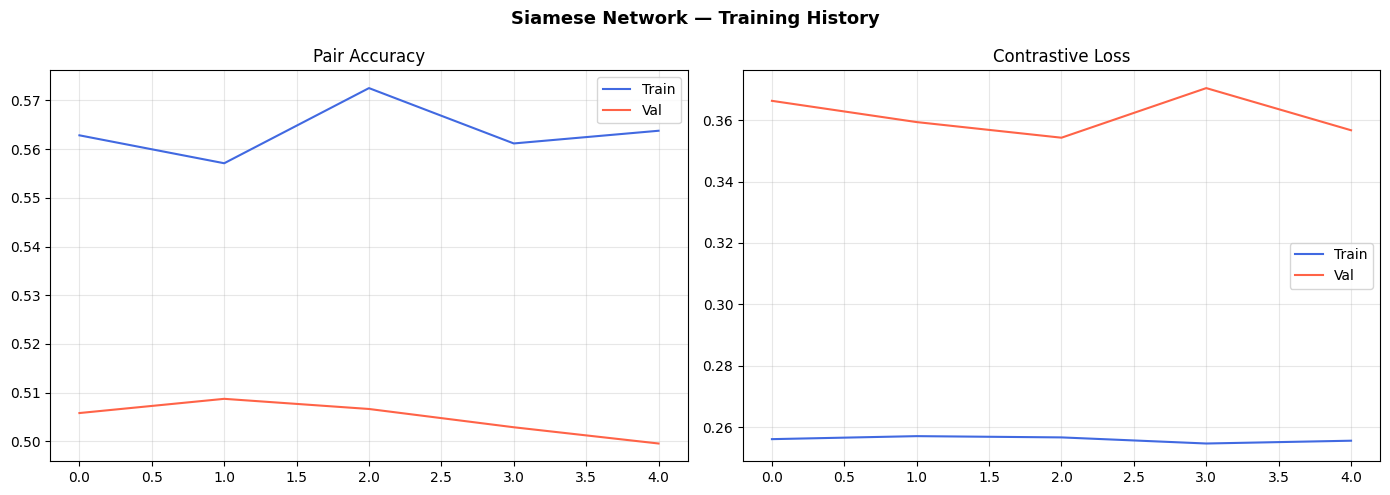

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Siamese Network — Training History", fontsize=13, fontweight='bold')

axes[0].plot(history_siamese.history['contrastive_accuracy'],
             label='Train', color='royalblue')
axes[0].plot(history_siamese.history['val_contrastive_accuracy'],
             label='Val', color='tomato')
axes[0].set_title('Pair Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_siamese.history['loss'],     label='Train', color='royalblue')
axes[1].plot(history_siamese.history['val_loss'], label='Val',   color='tomato')
axes[1].set_title('Contrastive Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('siamese_training_history.png', dpi=150)
plt.show()

In [ ]:
def compute_class_prototypes(embed_model, class_dict,
                              max_per_class=30, img_size=224):
    """Hitung centroid embedding tiap kelas dari subset train."""
    prototypes = {}
    print("Menghitung class prototypes...")
    for cls, img_paths in class_dict.items():
        embeddings = []
        for p in img_paths[:max_per_class]:
            img = load_image(p, img_size)
            emb = embed_model.predict(np.expand_dims(img, 0), verbose=0)[0]
            embeddings.append(emb)
        if embeddings:
            prototypes[cls] = np.mean(embeddings, axis=0)
    print(f"Prototypes siap: {len(prototypes)} kelas")
    return prototypes


def classify_by_prototype(embed_model, img_path, prototypes, img_size=224):
    """Klasifikasi satu gambar berdasarkan kedekatan ke prototype."""
    img = load_image(img_path, img_size)
    emb = embed_model.predict(np.expand_dims(img, 0), verbose=0)[0]
    distances = {cls: np.linalg.norm(emb - proto)
                 for cls, proto in prototypes.items()}
    return min(distances, key=distances.get), distances


def evaluate_prototype_classifier(embed_model, class_dict, prototypes,
                                   max_per_class=20, img_size=224):
    """Evaluasi prototype classifier pada test set."""
    classes    = sorted(list(class_dict.keys()))
    cls_to_idx = {c: i for i, c in enumerate(classes)}
    y_true, y_pred = [], []

    print("Evaluasi prototype classifier...")
    for cls in classes:
        for p in class_dict.get(cls, [])[:max_per_class]:
            pred_cls, _ = classify_by_prototype(embed_model, p, prototypes, img_size)
            y_true.append(cls_to_idx[cls])
            y_pred.append(cls_to_idx.get(pred_cls, -1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = np.mean(y_true == y_pred)
    print(f"Prototype Classifier Accuracy: {acc*100:.2f}%")
    return y_true, y_pred, acc


# Hitung prototype dari train set
class_prototypes = compute_class_prototypes(
    embed_net, train_class_dict, max_per_class=30, img_size=IMG_SIZE)

# Evaluasi pada test set
y_true_proto, y_pred_proto, proto_acc = evaluate_prototype_classifier(
    embed_net, test_class_dict, class_prototypes,
    max_per_class=20, img_size=IMG_SIZE)

Menghitung class prototypes...
Prototypes siap: 16 kelas
Evaluasi prototype classifier...
Prototype Classifier Accuracy: 37.81%


In [ ]:
classes = sorted(list(test_class_dict.keys()))

print("="*60)
print("Classification Report — Siamese Prototype Classifier")
print("="*60)
print(classification_report(y_true_proto, y_pred_proto,
                             target_names=classes, zero_division=0))

Classification Report — Siamese Prototype Classifier
                        precision    recall  f1-score   support

            Apple Scab       0.10      0.10      0.10        20
        Bacterial Spot       0.26      0.35      0.30        20
             Black Rot       0.00      0.00      0.00        20
      Cedar Apple Rust       0.29      0.10      0.15        20
  Cercospora Leaf Spot       0.50      0.40      0.44        20
          Common Rust        0.89      0.85      0.87        20
          Early Blight       0.55      0.60      0.57        20
  Esca (Black Measles)       1.00      0.85      0.92        20
               Healthy       0.19      0.25      0.22        20
           Late Blight       0.10      0.15      0.12        20
           Leaf Blight       0.76      0.80      0.78        20
           Leaf Scorch       0.19      0.20      0.20        20
  Northern Leaf Blight       0.50      0.45      0.47        20
        Powdery Mildew       0.29      0.35      0

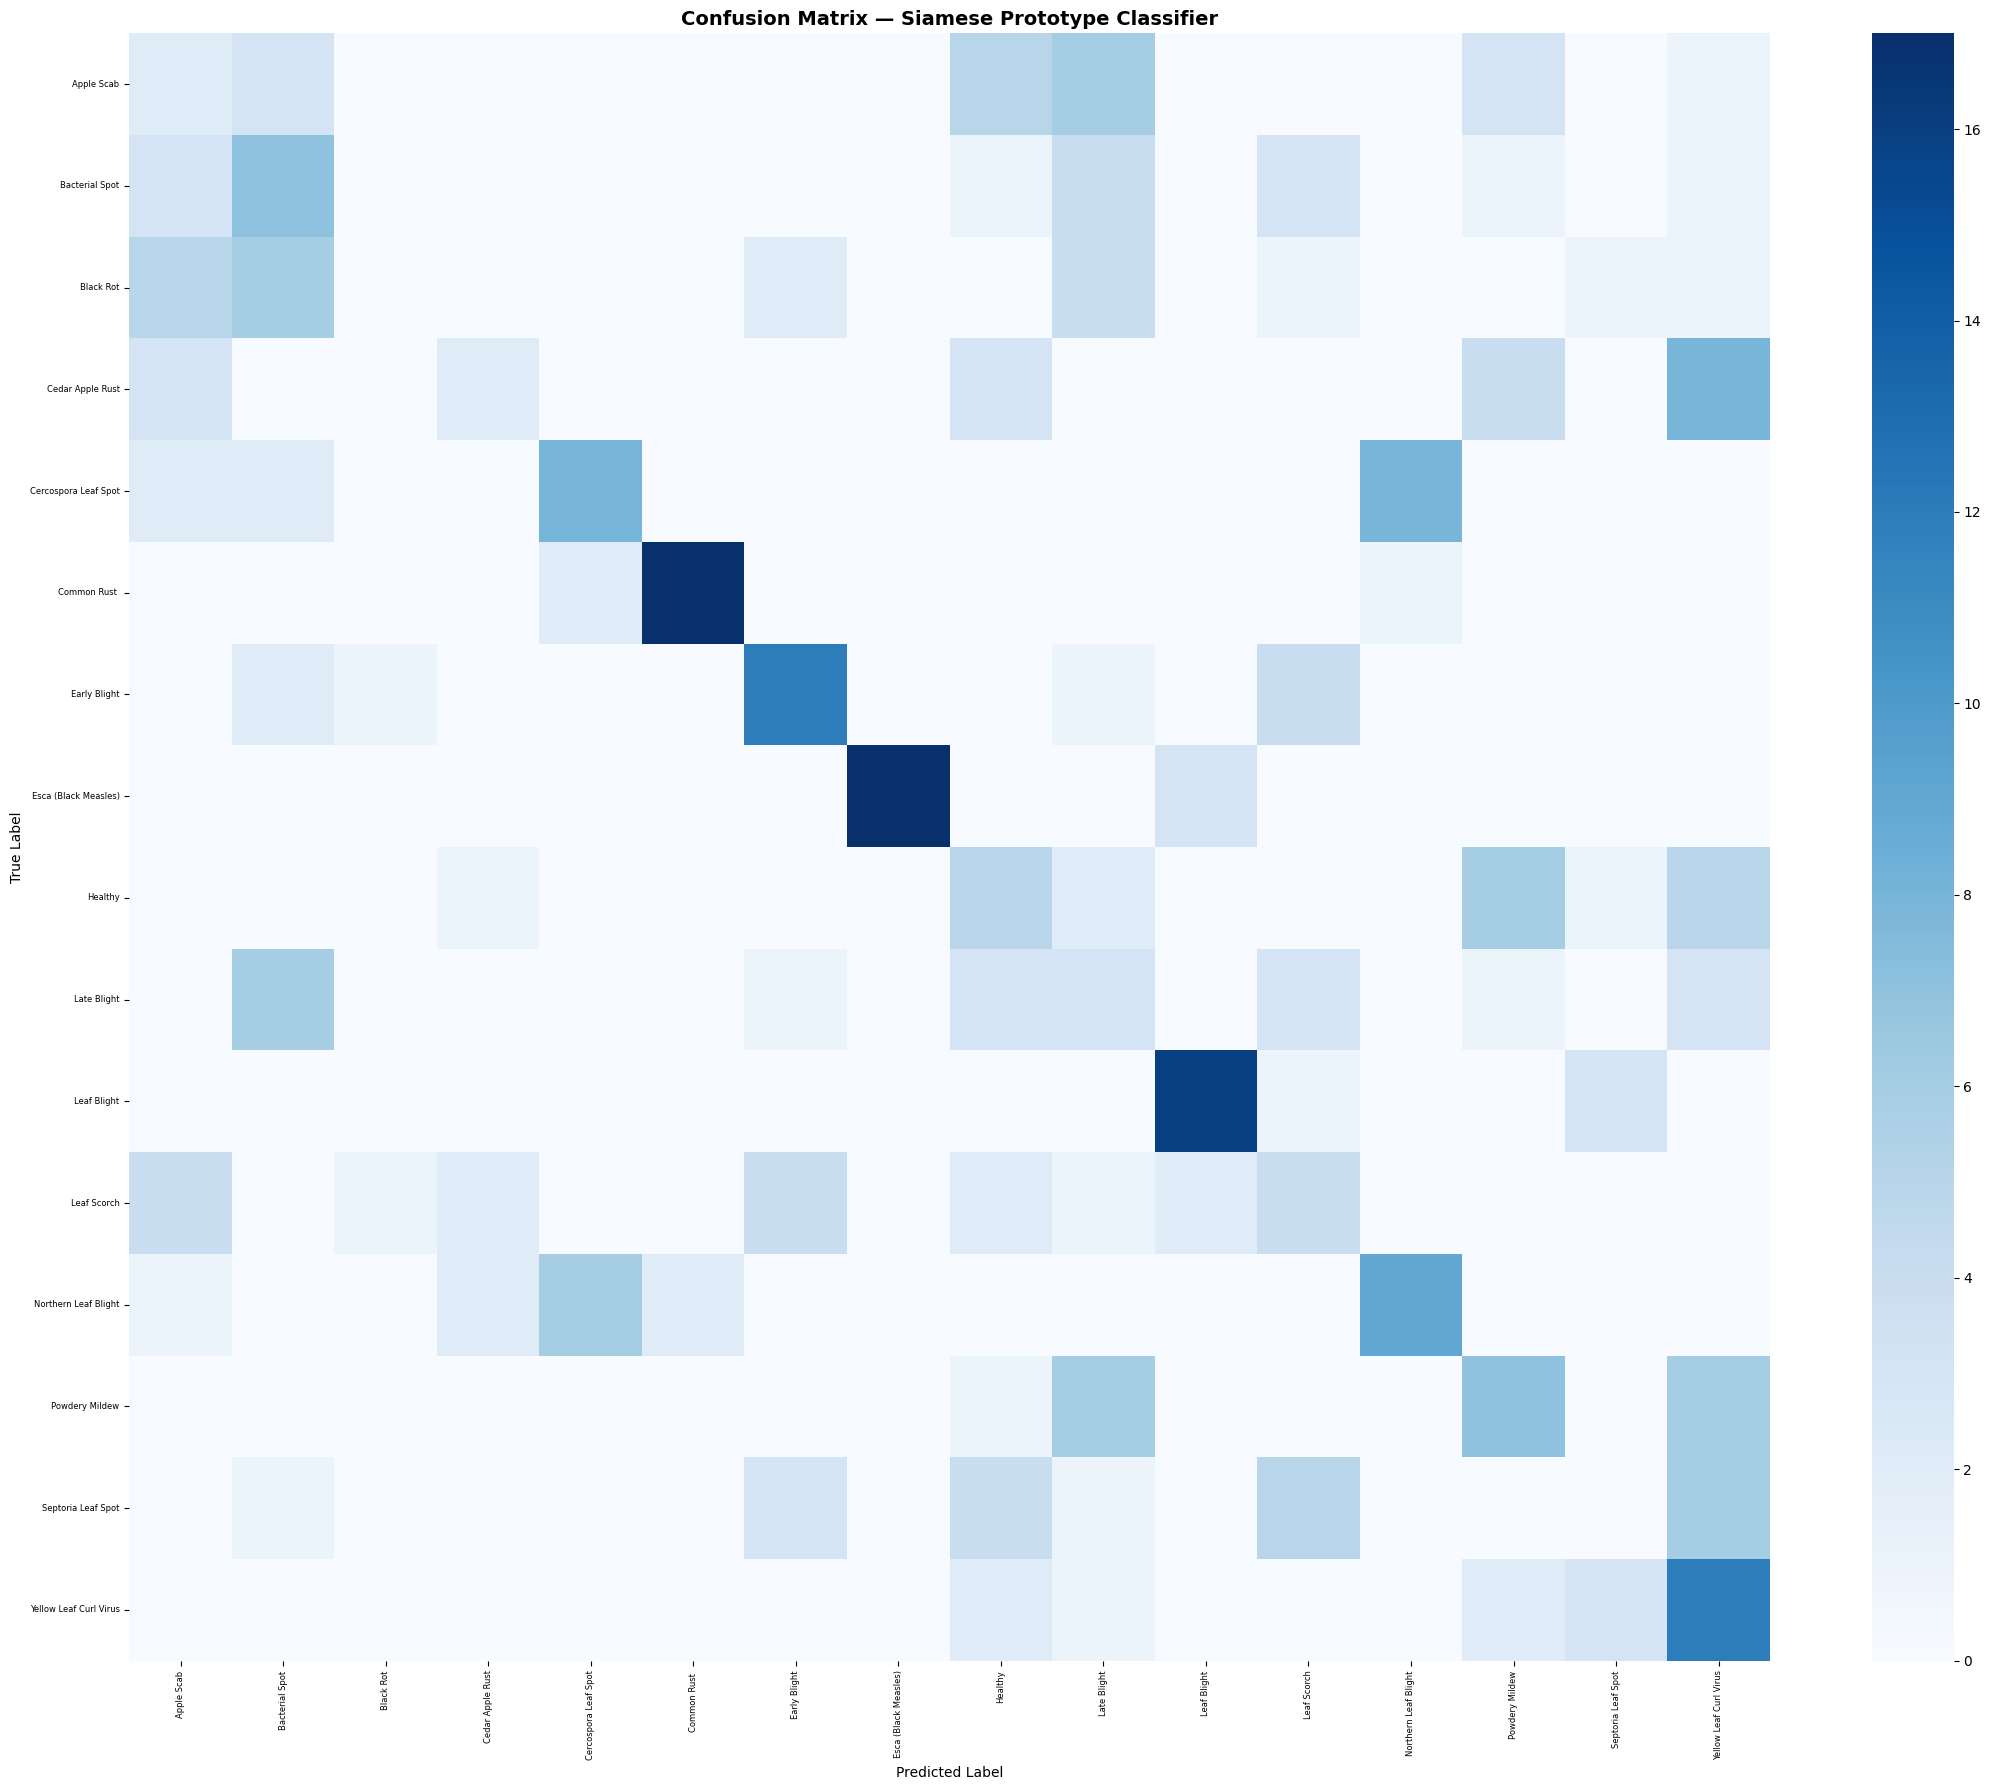

In [ ]:
cm = confusion_matrix(y_true_proto, y_pred_proto)
plt.figure(figsize=(22, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix — Siamese Prototype Classifier', fontsize=14, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=90, fontsize=6); plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig('confusion_matrix_siamese.png', dpi=150)
plt.show()

In [ ]:
siamese_model.save('model_siamese_plantvillage.keras')
embed_net.save('model_embedding_plantvillage.keras')
print("Model tersimpan!")

try:
    df_prev = pd.read_csv('results_all.csv')
except FileNotFoundError:
    df_prev = pd.DataFrame(columns=['Model', 'Test Loss', 'Test Acc', 'Top3 Acc'])

siamese_row = pd.DataFrame([
    {
        'Model'    : 'Siamese (Prototype Classifier)',
        'Test Loss': '-',
        'Test Acc' : round(proto_acc, 4),
        'Top3 Acc' : '-'
    }
])
df_all = pd.concat([df_prev, siamese_row], ignore_index=True)
df_all.to_csv('results_all.csv', index=False)

# Define best_val_acc from the val_acc list available from the previous training history
best_val_acc = max(val_acc) if val_acc else 0.0 # Assign 0.0 if val_acc is empty for safety

print("\n" + "="*60)
print("RINGKASAN — SIAMESE NETWORK")
print("="*60)
print(f"  Backbone         : MobileNetV2 (ImageNet)")
print(f"  Loss             : Contrastive Loss (margin={MARGIN})")
print(f"  Embed dim        : {EMBED_DIM}")
print(f"  Pair Accuracy    : {best_val_acc*100:.2f}% (val, binary)")
print(f"  Prototype Acc    : {proto_acc*100:.2f}% (test, multi-class)")
print(f"  Kelas            : {NUM_CLASSES}")
print("="*60)
print("File tersimpan:")
print("  - model_siamese_plantvillage.keras")
print("  - model_embedding_plantvillage.keras")
print("  - siamese_training_history.png")
print("  - confusion_matrix_siamese.png")
print("  - results_all.csv")


Model tersimpan!

RINGKASAN — SIAMESE NETWORK
  Backbone         : MobileNetV2 (ImageNet)
  Loss             : Contrastive Loss (margin=1.0)
  Embed dim        : 128
  Pair Accuracy    : 50.88% (val, binary)
  Prototype Acc    : 37.81% (test, multi-class)
  Kelas            : 16
File tersimpan:
  - model_siamese_plantvillage.keras
  - model_embedding_plantvillage.keras
  - siamese_training_history.png
  - confusion_matrix_siamese.png
  - results_all.csv


PERBANDINGAN SEMUA MODEL

Tabel Perbandingan:
                            Model Test Loss  Test Acc Top3 Acc
0                   CNN Sederhana    0.3952    0.8993   0.9907
1                  EfficientNetB0    2.7714    0.0675      0.2
2  Siamese (Prototype Classifier)         -    0.3781        -
3  Siamese (Prototype Classifier)         -    0.3781        -
4  Siamese (Prototype Classifier)         -    0.3781        -
5  Siamese (Prototype Classifier)         -    0.3781        -


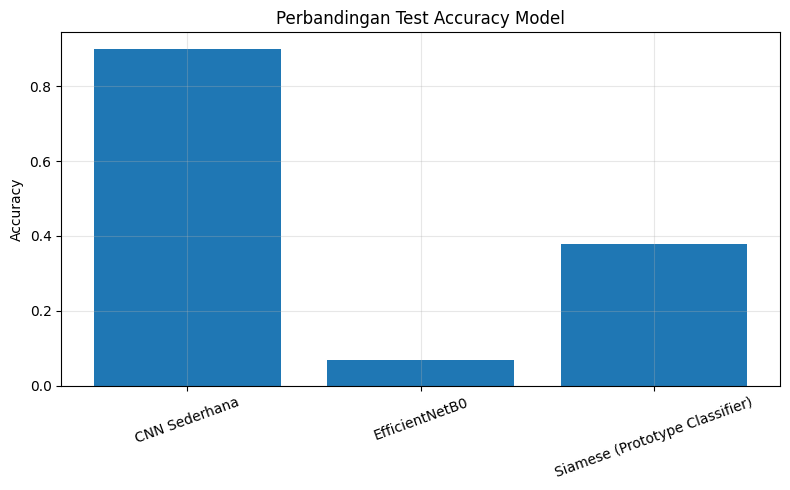

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("="*60)
print("PERBANDINGAN SEMUA MODEL")
print("="*60)

df_cnn = pd.read_csv('results_cnn_sederhana.csv')
df_eff = pd.read_csv('results_efficientnet.csv')

try:
    df_siam = pd.read_csv('results_all.csv')
except:
    df_siam = pd.DataFrame()

df_all = pd.concat([df_cnn, df_eff, df_siam], ignore_index=True)

print("\nTabel Perbandingan:")
print(df_all)

df_all.to_csv('results_comparison_final.csv', index=False)

df_plot = df_all[df_all['Test Acc'] != '-'].copy()
df_plot['Test Acc'] = df_plot['Test Acc'].astype(float)

plt.figure(figsize=(8,5))
plt.bar(df_plot['Model'], df_plot['Test Acc'])
plt.title("Perbandingan Test Accuracy Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_accuracy.png", dpi=150)
plt.show()